# 02 — Preprocessing & Feature Engineering
## Predictive Hospital Readmission Risk for Chronic Disease Patients

### Objective

Prepare the UCI Diabetes 130-US Hospitals dataset for machine learning.

This notebook performs:

- Data cleaning
- Missing-value handling
- Target transformation
- Diagnosis feature engineering
- Feature selection
- Train/validation/test splitting
- Categorical encoding
- Numerical scaling
- ML-ready dataset generation

### Project Prediction Point

The model is designed to make a prediction **at discharge**, using information available from the current hospitalization.

The application does not track or retrieve previous patient records.

### Target

Original target:

`readmitted`

Binary target:

- `<30` → `1` → Readmitted within 30 days
- `>30` → `0`
- `NO` → `0`

### Important Leakage Rule

The preprocessing transformations are fitted **only on the training set** and then applied to validation/test sets.

Patient identifiers are never used as model features.

`patient_nbr` may be used only to create patient-group-aware dataset splits so that encounters from the same patient are not unnecessarily distributed across training and evaluation sets.

## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from joblib import dump

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Raw Dataset

In [2]:
DATA_PATH = Path("../data/diabetic_data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Make sure diabetic_data.csv is inside ml-training/data/"
    )

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")
print(f"Path    : {DATA_PATH.resolve()}")

Dataset loaded successfully.
Rows    : 101,766
Columns : 50
Path    : D:\hospital-readmission-project\ml-training\data\diabetic_data.csv


## 3. Create Analysis/Processing Copy

The original `df` remains unchanged.

The UCI CSV commonly uses `?` for missing values.

We convert `?` to `NaN`.

We intentionally **do not convert `"None"` to missing** because in fields such as `A1Cresult` and `max_glu_serum`, `"None"` represents that the test was not measured and can therefore be informative.

In [3]:
data = df.copy()

# Standard missing marker
data = data.replace("?", np.nan)

# Clean whitespace from object columns
object_columns = data.select_dtypes(include="object").columns

for column in object_columns:
    data[column] = data[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Processing copy created.")
print(f"Missing values after '?' conversion: {data.isna().sum().sum():,}")

Processing copy created.
Missing values after '?' conversion: 374,017


## 4. Create the 30-Day Readmission Target

In [4]:
target_values = (
    data["readmitted"]
    .astype(str)
    .str.strip()
    .str.upper()
)

allowed_target_values = {"NO", ">30", "<30"}

unexpected_values = set(target_values.unique()) - allowed_target_values

if unexpected_values:
    raise ValueError(
        f"Unexpected readmitted values found: {unexpected_values}"
    )

data["readmitted_30"] = target_values.map({
    "<30": 1,
    ">30": 0,
    "NO": 0
}).astype(int)

print("30-day target created successfully.")

display(
    data["readmitted_30"]
    .value_counts()
    .sort_index()
    .rename_axis("Class")
    .to_frame("Count")
)

30-day target created successfully.


,Count
Class,
0,90409
1,11357


## 5. Diagnosis Feature Engineering

The raw dataset contains ICD-9 diagnosis codes:

- `diag_1`
- `diag_2`
- `diag_3`

Raw diagnosis codes can have many unique values and are not suitable as simple numerical values.

We therefore convert them into clinically meaningful broad diagnosis groups.

This reduces dimensionality and makes the feature more understandable.

In [ ]:
def diagnosis_group(code):
    """
    Convert an ICD-9 diagnosis code into a broad clinical category.
    """

    if pd.isna(code):
        return "Unknown"

    code = str(code).strip().upper()

    if code == "":
        return "Unknown"

    # ICD-9 supplementary codes
    if code.startswith("V"):
        return "Supplementary"

    # ICD-9 external cause codes
    if code.startswith("E"):
        return "External_Cause"

    # Extract numeric part
    match = re.match(r"^(\d+)", code)

    if not match:
        return "Unknown"

    number = int(match.group(1))

    # More specific categories first
    if number == 250:
        return "Diabetes"

    if 140 <= number <= 239:
        return "Neoplasms"

    if 1 <= number <= 139:
        return "Infectious"

    if 240 <= number <= 249 or 251 <= number <= 279:
        return "Endocrine_Metabolic"

    if 280 <= number <= 289:
        return "Blood"

    if 290 <= number <= 319:
        return "Mental"

    if 320 <= number <= 389:
        return "Nervous_System"

    if 390 <= number <= 459 or number == 785:
        return "Circulatory"

    if 460 <= number <= 519 or number == 786:
        return "Respiratory"

    if 520 <= number <= 579 or number == 787:
        return "Digestive"

    if 580 <= number <= 629 or number == 788:
        return "Genitourinary"

    if 630 <= number <= 679:
        return "Pregnancy"

    if 680 <= number <= 709 or number == 782:
        return "Skin"

    if 710 <= number <= 739:
        return "Musculoskeletal"

    if 740 <= number <= 759:
        return "Congenital"

    if 760 <= number <= 779:
        return "Perinatal"

    if 780 <= number <= 799:
        return "Symptoms_IllDefined"

    if 800 <= number <= 999:
        return "Injury"

    return "Other"

In [8]:
diagnosis_columns = [
    "diag_1",
    "diag_2",
    "diag_3"
]

for column in diagnosis_columns:
    new_column = f"{column}_group"
    data[new_column] = data[column].apply(diagnosis_group)

print("Diagnosis groups created.")

display(
    data[
        [
            "diag_1",
            "diag_1_group",
            "diag_2",
            "diag_2_group",
            "diag_3",
            "diag_3_group"
        ]
    ].head(10)
)

Diagnosis groups created.


,diag_1,diag_1_group,diag_2,diag_2_group,diag_3,diag_3_group
0,250.83,Diabetes,NaN,Unknown,NaN,Unknown
1,276,Endocrine_Metabolic,250.01,Diabetes,255,Endocrine_Metabolic
2,648,Pregnancy,250,Diabetes,V27,Supplementary
3,8,Infectious,250.43,Diabetes,403,Circulatory
4,197,Neoplasms,157,Neoplasms,250,Diabetes
5,414,Circulatory,411,Circulatory,250,Diabetes
6,414,Circulatory,411,Circulatory,V45,Supplementary
7,428,Circulatory,492,Respiratory,250,Diabetes
8,398,Circulatory,427,Circulatory,38,Infectious
9,434,Circulatory,198,Neoplasms,486,Respiratory


In [9]:
for column in [
    "diag_1_group",
    "diag_2_group",
    "diag_3_group"
]:
    print(f"\n{column}")
    display(
        data[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .to_frame("Count")
    )


diag_1_group


,Count
diag_1_group,
Circulatory,30437
Respiratory,14423
Digestive,9475
Diabetes,8757
Injury,6974
Genitourinary,5117
Musculoskeletal,4957
Neoplasms,3433
Symptoms_IllDefined,3129



diag_2_group


,Count
diag_2_group,
Circulatory,31881
Diabetes,12794
Respiratory,10895
Genitourinary,8376
Endocrine_Metabolic,8223
Digestive,4170
Skin,3670
Blood,2926
Symptoms_IllDefined,2801



diag_3_group


,Count
diag_3_group,
Circulatory,30306
Diabetes,17157
Endocrine_Metabolic,9151
Respiratory,7358
Genitourinary,6680
Digestive,3930
Supplementary,3814
Mental,3136
Symptoms_IllDefined,2721


## 6. Define the Final Model Features

### Current model design

The model uses information from the current hospital encounter and information available by discharge.

### Patient information
- Age
- Gender

### Admission information
- Admission type
- Admission source

### Clinical information
- Primary diagnosis group
- Secondary diagnosis group
- Other diagnosis group
- Number of diagnoses

### Laboratory information
- A1C result
- Maximum glucose result

### Hospitalization information
- Time in hospital
- Number of laboratory procedures
- Number of procedures
- Number of medications

### Treatment information
- Diabetes medication
- Medication change
- Insulin

### Discharge information
- Discharge disposition

### Deliberately excluded

- `encounter_id`
- `patient_nbr`
- `number_outpatient`
- `number_emergency`
- `number_inpatient`

The previous-utilization variables are excluded because this prototype does not retrieve or track a patient's previous records.

`race` is retained for analysis/fairness investigation but is not included in the primary model feature set.

In [10]:
categorical_features = [
    "age",
    "gender",
    "admission_type_id",
    "admission_source_id",
    "discharge_disposition_id",
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",
    "A1Cresult",
    "max_glu_serum",
    "diabetesMed",
    "change",
    "insulin",
]

numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses",
]

final_features = categorical_features + numeric_features

print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features  : {len(numeric_features)}")
print(f"Total model inputs  : {len(final_features)}")

print("\nFinal features:")
for i, feature in enumerate(final_features, start=1):
    print(f"{i:02d}. {feature}")

Categorical features: 13
Numerical features  : 5
Total model inputs  : 18

Final features:
01. age
02. gender
03. admission_type_id
04. admission_source_id
05. discharge_disposition_id
06. diag_1_group
07. diag_2_group
08. diag_3_group
09. A1Cresult
10. max_glu_serum
11. diabetesMed
12. change
13. insulin
14. time_in_hospital
15. num_lab_procedures
16. num_procedures
17. num_medications
18. number_diagnoses


## 7. Prepare Feature Data

The feature matrix contains only variables that can be used by the model.

`patient_nbr` is kept temporarily as a **group identifier for dataset splitting only**.

It will never enter the model.

In [11]:
required_columns = (
    final_features
    + ["readmitted_30", "patient_nbr"]
)

missing_final_columns = [
    column
    for column in required_columns
    if column not in data.columns
]

if missing_final_columns:
    raise ValueError(
        f"Required columns missing: {missing_final_columns}"
    )

model_data = data[required_columns].copy()

print("Model dataset created.")
print(f"Shape: {model_data.shape}")

Model dataset created.
Shape: (101766, 20)


## 8. Clean Feature Types

Categorical features are treated as categories.

Numerical features are explicitly converted to numeric values.

Unknown or invalid gender values are treated as missing and will be imputed during preprocessing.

In [12]:
# Standardize invalid gender value
if "gender" in model_data.columns:
    model_data["gender"] = model_data["gender"].replace(
        "Unknown/Invalid",
        np.nan
    )

# Convert numerical columns to numeric
for column in numeric_features:
    model_data[column] = pd.to_numeric(
        model_data[column],
        errors="coerce"
    )

# Ensure categorical columns are strings/objects
for column in categorical_features:
    model_data[column] = model_data[column].astype("object")

print("Feature types cleaned.")
display(model_data.dtypes.to_frame("Data Type"))

Feature types cleaned.


,Data Type
age,object
gender,object
admission_type_id,object
admission_source_id,object
discharge_disposition_id,object
diag_1_group,object
diag_2_group,object
diag_3_group,object
A1Cresult,object
max_glu_serum,object


## 9. Check Missing Values Before Encoding

In [13]:
missing_summary = pd.DataFrame({
    "Missing Count": model_data[final_features].isna().sum(),
    "Missing Percentage": (
        model_data[final_features].isna().mean() * 100
    ).round(2)
}).sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
gender,3,0.00
age,0,0.00
admission_type_id,0,0.00
admission_source_id,0,0.00
diag_1_group,0,0.00
discharge_disposition_id,0,0.00
diag_3_group,0,0.00
diag_2_group,0,0.00


### Missing-value strategy

We will use:

**Numerical features**
- Median imputation

**Categorical features**
- Most-frequent imputation

For `A1Cresult` and `max_glu_serum`, the dataset value `"None"` is retained as a legitimate category meaning the test was not measured. It is therefore not treated as a missing value during this stage.

## 10. Build Patient-Group-Aware Train / Validation / Test Splits

The dataset can contain multiple encounters for the same patient.

A normal random split can place different encounters from the same patient into both training and evaluation data.

To reduce this leakage risk, `patient_nbr` is used **only as a grouping variable**.

It is never used as a model feature.

We use 5 stratified group folds:

- approximately 60% training
- approximately 20% validation
- approximately 20% testing

In [14]:
X_raw = model_data[final_features].copy()
y = model_data["readmitted_30"].copy()
groups = model_data["patient_nbr"].copy()

if y.isna().any():
    raise ValueError("Target contains missing values.")

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    splitter.split(
        X_raw,
        y,
        groups=groups
    )
)

# First fold -> test
test_indices = folds[0][1]

# Second fold -> validation
validation_indices = folds[1][1]

# Remaining folds -> training
all_indices = np.arange(len(model_data))

excluded_indices = np.concatenate([
    test_indices,
    validation_indices
])

train_indices = np.setdiff1d(
    all_indices,
    excluded_indices
)

print(f"Training records   : {len(train_indices):,}")
print(f"Validation records : {len(validation_indices):,}")
print(f"Test records       : {len(test_indices):,}")

print(
    f"\nTrain percentage: "
    f"{len(train_indices) / len(model_data) * 100:.2f}%"
)

print(
    f"Validation percentage: "
    f"{len(validation_indices) / len(model_data) * 100:.2f}%"
)

print(
    f"Test percentage: "
    f"{len(test_indices) / len(model_data) * 100:.2f}%"
)

Training records   : 61,058
Validation records : 20,354
Test records       : 20,354

Train percentage: 60.00%
Validation percentage: 20.00%
Test percentage: 20.00%


In [15]:
X_train = X_raw.iloc[train_indices].copy()
X_val = X_raw.iloc[validation_indices].copy()
X_test = X_raw.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_val = y.iloc[validation_indices].copy()
y_test = y.iloc[test_indices].copy()

groups_train = groups.iloc[train_indices]
groups_val = groups.iloc[validation_indices]
groups_test = groups.iloc[test_indices]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (61058, 18)
Validation shape: (20354, 18)
Test shape: (20354, 18)


## 11. Verify Target Distribution Across Splits

In [16]:
split_target_summary = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}).fillna(0) * 100

split_target_summary.index = [
    "Not Readmitted Within 30 Days",
    "Readmitted Within 30 Days"
]

display(split_target_summary.round(2))

,Train,Validation,Test
Not Readmitted Within 30 Days,88.84,88.84,88.84
Readmitted Within 30 Days,11.16,11.16,11.16


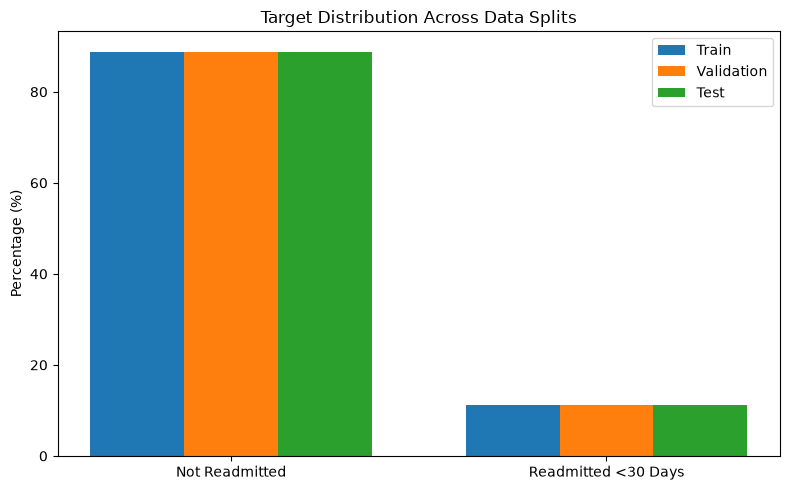

In [17]:
plt.figure(figsize=(8, 5))

x = np.arange(2)
width = 0.25

plt.bar(
    x - width,
    split_target_summary["Train"],
    width,
    label="Train"
)

plt.bar(
    x,
    split_target_summary["Validation"],
    width,
    label="Validation"
)

plt.bar(
    x + width,
    split_target_summary["Test"],
    width,
    label="Test"
)

plt.xticks(
    x,
    [
        "Not Readmitted",
        "Readmitted <30 Days"
    ]
)

plt.ylabel("Percentage (%)")
plt.title("Target Distribution Across Data Splits")
plt.legend()

plt.tight_layout()
plt.show()

## 12. Build the Leakage-Safe Preprocessing Pipeline

### Numerical features

1. Median imputation
2. Standard scaling

### Categorical features

1. Most-frequent imputation
2. One-hot encoding

The preprocessing pipeline is fitted **only on the training data**.

Validation and test data are transformed using the already-fitted training pipeline.

In [18]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Compatibility with different scikit-learn versions
try:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )
except TypeError:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        categorical_encoder
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 13. Fit Preprocessor Only on Training Data

In [19]:
preprocessor.fit(X_train)

print("Preprocessor fitted using TRAINING data only.")

Preprocessor fitted using TRAINING data only.


In [20]:
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Transformation completed.")

print("Processed train shape :", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape  :", X_test_processed.shape)

Transformation completed.
Processed train shape : (61058, 141)
Processed validation shape: (20354, 141)
Processed test shape  : (20354, 141)


## 14. Verify Processed Data

The categorical variables should now be one-hot encoded and the numerical variables standardized.

The number of final ML features can be larger than the original 18 input fields because categorical values create multiple encoded columns.

In [21]:
feature_names = preprocessor.get_feature_names_out()

print(f"Original model inputs : {len(final_features)}")
print(f"Encoded ML features   : {len(feature_names)}")

print("\nFirst 50 encoded features:")
for feature in feature_names[:50]:
    print(feature)

Original model inputs : 18
Encoded ML features   : 141

First 50 encoded features:
numeric__time_in_hospital
numeric__num_lab_procedures
numeric__num_procedures
numeric__num_medications
numeric__number_diagnoses
categorical__age_[0-10)
categorical__age_[10-20)
categorical__age_[20-30)
categorical__age_[30-40)
categorical__age_[40-50)
categorical__age_[50-60)
categorical__age_[60-70)
categorical__age_[70-80)
categorical__age_[80-90)
categorical__age_[90-100)
categorical__gender_Female
categorical__gender_Male
categorical__admission_type_id_1
categorical__admission_type_id_2
categorical__admission_type_id_3
categorical__admission_type_id_4
categorical__admission_type_id_5
categorical__admission_type_id_6
categorical__admission_type_id_7
categorical__admission_type_id_8
categorical__admission_source_id_1
categorical__admission_source_id_2
categorical__admission_source_id_3
categorical__admission_source_id_4
categorical__admission_source_id_5
categorical__admission_source_id_6
categorical_

## 15. Check for NaN / Infinite Values After Preprocessing

In [22]:
def check_processed_matrix(matrix, name):
    # Sparse matrices have the `toarray()` method.
    dense_matrix = matrix.toarray() if hasattr(matrix, "toarray") else matrix

    nan_count = np.isnan(dense_matrix).sum()
    inf_count = np.isinf(dense_matrix).sum()

    print(f"{name}")
    print(f"NaN values     : {nan_count:,}")
    print(f"Infinite values: {inf_count:,}")
    print("-" * 40)

    return nan_count, inf_count


check_processed_matrix(X_train_processed, "Training Set")
check_processed_matrix(X_val_processed, "Validation Set")
check_processed_matrix(X_test_processed, "Test Set")

Training Set
NaN values     : 0
Infinite values: 0
----------------------------------------
Validation Set
NaN values     : 0
Infinite values: 0
----------------------------------------
Test Set
NaN values     : 0
Infinite values: 0
----------------------------------------


(np.int64(0), np.int64(0))

## 16. Class Imbalance

The readmission-within-30-days class is expected to be smaller than the non-readmission class.

We will **not apply SMOTE or oversampling in this notebook**.

Class imbalance handling will be evaluated during model training using appropriate techniques such as:

- class weighting
- threshold analysis
- or carefully applied resampling on the training data only

This prevents information from the validation/test sets from influencing training.

In [23]:
class_distribution = pd.DataFrame({
    "Class": [0, 1],
    "Meaning": [
        "Not readmitted within 30 days",
        "Readmitted within 30 days"
    ],
    "Training Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum()
    ],
    "Validation Count": [
        (y_val == 0).sum(),
        (y_val == 1).sum()
    ],
    "Test Count": [
        (y_test == 0).sum(),
        (y_test == 1).sum()
    ]
})

display(class_distribution)

,Class,Meaning,Training Count,Validation Count,Test Count
0,0,Not readmitted within 30 days,54244,18083,18082
1,1,Readmitted within 30 days,6814,2271,2272


## 17. Save ML-Ready Data and Preprocessor

The following files will be generated:

`data/processed/model_data.pkl`

Contains:

- training features
- validation features
- test features
- training targets
- validation targets
- test targets
- encoded feature names

`models/preprocessor.pkl`

Contains the preprocessing pipeline fitted on training data only.

The raw CSV remains unchanged.

In [25]:
processed_dir = Path("../data/processed")
models_dir = Path("../models")

processed_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

prepared_data = {
    "X_train": X_train_processed,
    "X_val": X_val_processed,
    "X_test": X_test_processed,
    "y_train": y_train.to_numpy(),
    "y_val": y_val.to_numpy(),
    "y_test": y_test.to_numpy(),
    "feature_names": feature_names,
    "final_features": final_features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features
}

DATA_OUTPUT_PATH = processed_dir / "model_data.pkl"
PREPROCESSOR_OUTPUT_PATH = models_dir / "preprocessor.pkl"

dump(
    prepared_data,
    DATA_OUTPUT_PATH,
    compress=3
)

dump(
    preprocessor,
    PREPROCESSOR_OUTPUT_PATH,
    compress=3
)

print("Files saved successfully:")
print(f"1. {DATA_OUTPUT_PATH.resolve()}")
print(f"2. {PREPROCESSOR_OUTPUT_PATH.resolve()}")

Files saved successfully:
1. D:\hospital-readmission-project\ml-training\data\processed\model_data.pkl
2. D:\hospital-readmission-project\ml-training\models\preprocessor.pkl


## 18. Save Encoded Feature Names

In [26]:
FEATURE_NAMES_PATH = processed_dir / "feature_names.csv"

pd.DataFrame({
    "encoded_feature": feature_names
}).to_csv(
    FEATURE_NAMES_PATH,
    index=False
)

print(f"Feature names saved to:")
print(FEATURE_NAMES_PATH.resolve())

Feature names saved to:
D:\hospital-readmission-project\ml-training\data\processed\feature_names.csv


## 19. Final Validation Checks

In [27]:
checks = {
    "Raw dataset preserved": DATA_PATH.exists(),
    "30-day target created": "readmitted_30" in data.columns,
    "No identifier in model features": (
        "encounter_id" not in final_features
        and "patient_nbr" not in final_features
    ),
    "Historical utilization excluded": all(
        feature not in final_features
        for feature in [
            "number_outpatient",
            "number_emergency",
            "number_inpatient"
        ]
    ),
    "Training data prepared": X_train_processed.shape[0] > 0,
    "Validation data prepared": X_val_processed.shape[0] > 0,
    "Test data prepared": X_test_processed.shape[0] > 0,
    "Preprocessor saved": PREPROCESSOR_OUTPUT_PATH.exists(),
    "Prepared data saved": DATA_OUTPUT_PATH.exists()
}

validation_table = pd.DataFrame({
    "Check": list(checks.keys()),
    "Status": [
        "PASS" if value else "FAIL"
        for value in checks.values()
    ]
})

display(validation_table)

if not all(checks.values()):
    raise RuntimeError("One or more preprocessing validation checks failed.")

print("All preprocessing validation checks passed.")

,Check,Status
0,Raw dataset preserved,PASS
1,30-day target created,PASS
2,No identifier in model features,PASS
3,Historical utilization excluded,PASS
4,Training data prepared,PASS
5,Validation data prepared,PASS
6,Test data prepared,PASS
7,Preprocessor saved,PASS
8,Prepared data saved,PASS


All preprocessing validation checks passed.


# Conclusion

The dataset is now prepared for machine learning.

### Final prediction target

`readmitted_30`

- `1` = Readmitted within 30 days
- `0` = Not readmitted within 30 days

### Current model inputs

#### Patient
- `age`
- `gender`

#### Admission
- `admission_type_id`
- `admission_source_id`

#### Clinical
- `diag_1_group`
- `diag_2_group`
- `diag_3_group`
- `number_diagnoses`

#### Laboratory
- `A1Cresult`
- `max_glu_serum`

#### Hospitalization
- `time_in_hospital`
- `num_lab_procedures`
- `num_procedures`
- `num_medications`

#### Treatment
- `diabetesMed`
- `change`
- `insulin`

#### Discharge
- `discharge_disposition_id`

### Excluded
- `encounter_id`
- `patient_nbr`
- `number_outpatient`
- `number_emergency`
- `number_inpatient`

### Generated artifacts

- `data/processed/model_data.pkl`
- `data/processed/feature_names.csv`
- `models/preprocessor.pkl`

The data is now ready for:

**`03_Model_Training.ipynb`**